# Bio Weavers MVP — Demo Notebook

Quick walkthrough of the proof-of-life pipeline.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx

# Ensure repo root is on sys.path
repo_root = Path.cwd().resolve()
if (repo_root / 'src').exists():
    sys.path.insert(0, str(repo_root))
elif (repo_root.parent / 'src').exists():
    sys.path.insert(0, str(repo_root.parent))


In [2]:
from pathlib import Path

from src.geometry import load_boundary, create_buffer, get_bounding_box, load_all_quads, get_quads, get_species_cnps, get_species_cnddb, get_neighbors
from src.species import refactor_cnps, plot_cnddb_species_distribution, plot_cnddb_species_date_range, plot_species_map # get_unique_species, filter_federally_listed
# from src.export import export_species_csv, export_species_excel


<Axes: >

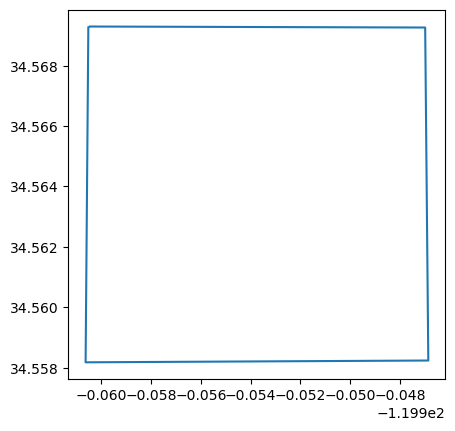

In [3]:
# Load sample boundary.
boundary_path = Path("../data/lake_cachuma.geojson")
boundary = load_boundary(boundary_path)
boundary.plot()

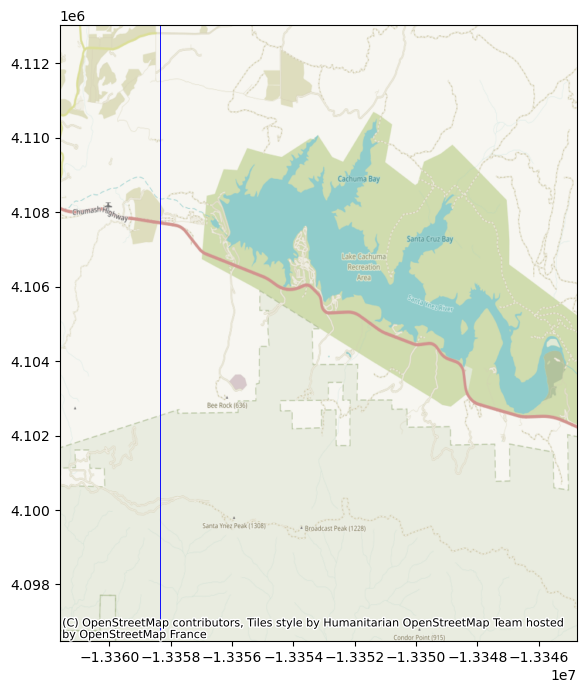

In [4]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# load your data
gdf = gpd.read_file("../data/lake_cachuma.geojson")

# load quadrangles
quads = gpd.read_file("../data/california_statewide_index_of_usgs_24k_7_5_minute_quad_topo_maps.geojson")

# IMPORTANT: convert to web mercator
gdf = gdf.to_crs(epsg=3857)
quads = quads.to_crs(epsg=3857)

# plot quadrangles first
ax = quads.plot(figsize=(8, 8),
                facecolor="none",
                edgecolor="blue",
                linewidth=0.5)

# plot boundary on top
boundary.plot(ax=ax,
              facecolor="none",
              edgecolor="red",
              linewidth=2)

xmin, ymin, xmax, ymax = gdf.total_bounds

# adjust this value to control zoom
zoom_factor = 5  # 20% extra space

xpad = (xmax - xmin) * zoom_factor
ypad = (ymax - ymin) * zoom_factor

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# add basemap
ctx.add_basemap(ax)

plt.show()

In [5]:
# Create a mile based buffer and bounding box.
buffered_2mi_boundary = create_buffer(boundary, distance=4828.03) # 2-miles in meters
bbox = get_bounding_box(buffered_2mi_boundary)
bbox

/opt/anaconda3/envs/bioweavers/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


array([-120.01326471,   34.51467481, -119.89422307,   34.61280126])

In [6]:
# Load in all quads in California.
all_quads_path = Path("../data/california_statewide_index_of_usgs_24k_7_5_minute_quad_topo_maps.geojson")
all_quads = load_all_quads(all_quads_path)

In [7]:
# Get the list of quads that intersect with the boundary.
quad_ids = get_quads(buffered_2mi_boundary, all_quads)
quad_ids

{3411958, 3412051}

In [8]:
# 9-quad buffer search.
buffer_quad_search = get_neighbors(quad_ids, all_quads)
buffer_quad_search

[3411968,
 3412041,
 3412042,
 3411947,
 3411948,
 3412051,
 3412052,
 3411957,
 3411958,
 3412061,
 3412062,
 3411967]

In [9]:
# Refactor CNPS Quad list.
cnps_path = Path("../data/CNPS_RAW.csv")
cnps = refactor_cnps(cnps_path)

In [10]:
# Get the CNPS species that are found within the intersecting quads.
cnps_species = get_species_cnps(cnps, quad_ids)
cnps_species.head()

,ScientificName,CommonName,Family,Lifeform,CRPR,GRank,SRank,OtherStatus,CESA,FESA,...,Taxonomy,FullScientificName,Synonyms,ElementCode,USDAPlantsSymbol,CBRReason,DateAdded,LastUpdate,CRPRChangeDate,split_quad
172,Arctostaphylos refugioensis,Refugio manzanita,Ericaceae,perennial evergreen shrub,1B.2,G3,S3,SB_SBBG; USFS_S,NaN,NaN,...,NaN,Arctostaphylos refugioensis,NaN,PDERI041B0,ARRE5,NaN,1/1/1974,10/29/2025,NaN,"[3412042, 3411947, 3411958, 3412064, 3412054, ..."
397,Calandrinia breweri,Brewer's calandrinia,Montiaceae,annual herb,4.2,G4,S4,SB_SBBG; SB_UCSC,NaN,NaN,...,NaN,Calandrinia breweri,NaN,PDPOR01020,CABR3,NaN,1/1/1994,10/29/2025,NaN,"[3812264, 3211677, 3712187, 3211666, 3612113, ..."
407,Calochortus fimbriatus,late-flowered mariposa-lily,Liliaceae,perennial bulbiferous herb,1B.3,G3,S3,BLM_S; SB_SBBG; USFS_S,NaN,NaN,...,NaN,Calochortus fimbriatus,Calochortus weedii var. vestus,PMLIL0D1J2,NaN,NaN,1/1/1994,10/29/2025,10/26/2012,"[3512183, 3512172, 3512173, 3512184, 3411945, ..."
717,Cordylanthus rigidus ssp. littoralis,seaside bird's-beak,Orobanchaceae,annual herb (hemiparasitic),1B.1,G5T2,S2,BLM_S; SB_CalBG/RSABG; SB_SBBG,CE,NaN,...,NaN,Cordylanthus rigidus ssp. littoralis (Ferris) ...,Cordylanthus littoralis ssp. littoralis,PDSCR0J0P2,CORIL,NaN,1/1/1980,10/29/2025,NaN,"[3412075, 3412064, 3412054, 3412063, 3612167, ..."
783,Deinandra paniculata,paniculate tarplant,Asteraceae,annual herb,4.2,G4,S4,NaN,NaN,NaN,...,NaN,Deinandra paniculata,NaN,PDAST4R0Y0,NaN,NaN,1/1/2001,10/29/2025,10/29/2012,"[3311647, 3311764, 3311656, 3512025, 3512046, ..."


In [11]:
# Get the CNDBB species that are found within the intersecting quads.
cnddb_path = Path("../data/mock_cnddb_data.geojson")
cnddb_species = get_species_cnddb(cnddb_path, quad_ids)
cnddb_species

,OBJECTID,SNAME,CNAME,ELMCODE,OCCNUMBER,MAPNDX,EONDX,KEYQUAD,KQUADNAME,KEYCOUNTY,...,THREATLIST,LASTUPDATE,AREA,PERIMETER,AVLCODE,Symbology,BUFF_DIST,Shape_Length,Shape_Area,geometry
14,3671,Enul joqui,river slug,IMA3ZPQ8VF,515.0,38419,176632,3411958,Lake Cachuma,VEN,...,,2004-11-08,20106.19298,502.654825,20101,201,80,502.654825,20106.19298,"POLYGON ((-119.9274 34.62331, -119.92731 34.62..."
15,3964,Xomi giha,silver grass,PMZ4472YCO,3.0,78025,317779,3411958,Lake Cachuma,LAX,...,,1991-10-27,20106.19298,502.654825,10101,101,80,502.654825,20106.19298,"POLYGON ((-119.95609 34.5607, -119.956 34.5606..."
19,5046,Sior palu bejo,ridge amphipod,IC55ZPNUJU,461.0,88979,401804,3411958,Lake Cachuma,ELD,...,,2004-08-23,20106.19298,502.654825,20101,201,80,502.654825,20106.19298,"POLYGON ((-119.95652 34.59028, -119.95643 34.5..."
23,5601,Orsi luzu,spotted amphipod,ICEMW3D14M,2.0,53219,175372,3411958,Lake Cachuma,ORE,...,,2020-05-17,20106.19298,502.654825,20101,201,80,502.654825,20106.19298,"POLYGON ((-119.97445 34.5859, -119.97436 34.58..."
28,7476,Ilal noya,spotted orchid,PMTYFC085I,9.0,17529,354044,3411958,Lake Cachuma,GLE,...,,1994-06-17,20106.19298,502.654825,10103,801,80,502.654825,20106.19298,"POLYGON ((-119.88386 34.59406, -119.88377 34.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,97386,Vaka ulwe,ridge lichen,NLCM6CF5C0,16.0,53952,184608,3411958,Lake Cachuma,TUO,...,,2008-02-18,70685.83471,942.477796,10401,104,150,942.477796,70685.83471,"POLYGON ((-119.93649 34.53585, -119.93637 34.5..."
393,97996,Lube gino,tidal orchid,PM49DH1JK0,92.0,90996,335072,3412051,Santa Ynez,SLO,...,,2002-03-16,70685.83471,942.477796,10402,804,150,942.477796,70685.83471,"POLYGON ((-120.1188 34.50881, -120.11868 34.50..."
395,98791,Xoha kail,windy lily,PM6UP53JU6,117.0,52529,197771,3412051,Santa Ynez,YUB,...,Nest parasitism,1987-10-29,70685.83471,942.477796,10401,104,150,942.477796,70685.83471,"POLYGON ((-120.04376 34.50427, -120.04364 34.5..."
396,98975,Sibe zuxo,silver sedge,PM54EE56J7,39.0,26685,325210,3412051,Santa Ynez,AMA,...,,2020-11-16,70685.83471,942.477796,10401,104,150,942.477796,70685.83471,"POLYGON ((-120.07799 34.53347, -120.07787 34.5..."


/var/folders/wp/mtdgn17111nf7blfwsl5pzlr0000gn/T/ipykernel_77463/2308491043.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  species_distribution_plot.show()


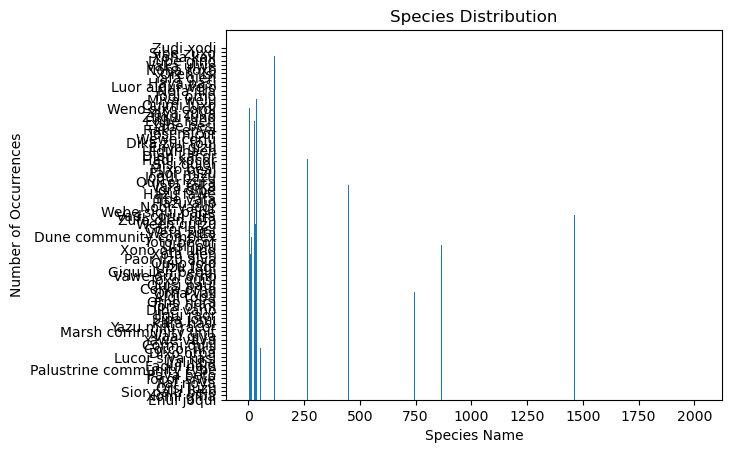

In [12]:
# Plot the distribution of CNDBB species occurrences.
species_distribution_plot = plot_cnddb_species_distribution(cnddb_species)
species_distribution_plot.show()

In [13]:
# Plot the date range of CNDBB species occurrences.
species_date_range_plot = plot_cnddb_species_date_range(cnddb_species)

/opt/anaconda3/envs/bioweavers/lib/python3.11/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


NameError: name 'ctx' is not defined

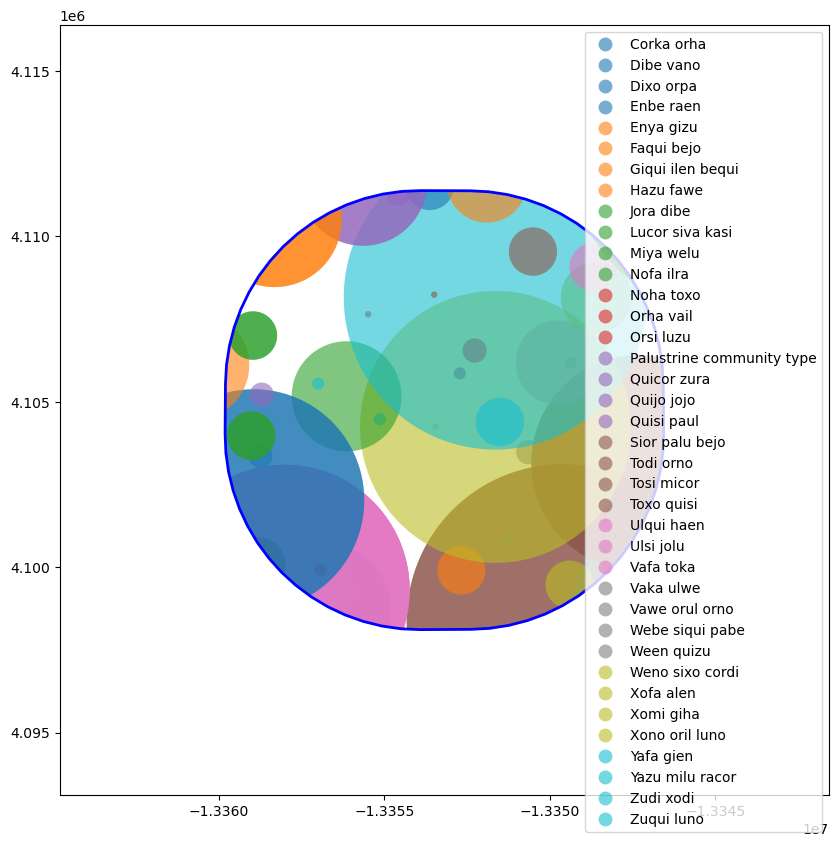

In [14]:
plot_species_map(cnddb_species, buffered_2mi_boundary)

In [ ]:
# # Build species list + filter federally listed
# species = get_unique_species(observations)
# listed = filter_federally_listed(species)
# species.head()

In [ ]:
# # Export outputs
# output_dir = Path("../output")
# export_species_csv(species, output_dir / "species.csv", project_name="Sample Project")
# export_species_excel(species, listed, output_dir / "species.xlsx", project_name="Sample Project")
